In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/joannaaa22/processed/emotion_test.csv
/kaggle/input/datasets/joannaaa22/processed/imdb_train.csv
/kaggle/input/datasets/joannaaa22/processed/sst2_test.csv
/kaggle/input/datasets/joannaaa22/processed/sst2_train.csv
/kaggle/input/datasets/joannaaa22/processed/imdb_val.csv
/kaggle/input/datasets/joannaaa22/processed/emotion_val.csv
/kaggle/input/datasets/joannaaa22/processed/sst2_val.csv
/kaggle/input/datasets/joannaaa22/processed/imdb_test.csv
/kaggle/input/datasets/joannaaa22/processed/emotion_train.csv


# **Imports and Setup**

In [2]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
from sklearn.metrics import classification_report
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
import gc

# Global Constants
BASE_PATH = "/kaggle/input/datasets/joannaaa22/processed"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TOKENIZER_NAME = "vinai/bertweet-base"
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 1e-3

MAPPINGS = {
    "imdb": {0: "negative", 1: "positive"},
    "sst2": {0: "negative", 1: "positive"},
    "emotion": {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
}

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
print(f"Running on: {DEVICE}")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Running on: cuda


# **Model Architecture**

In [3]:
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super(AttentionLayer, self).__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_output):
        scores = self.attn(lstm_output) 
        weights = F.softmax(scores, dim=1)
        context = torch.sum(weights * lstm_output, dim=1)
        return context, weights

class BiLSTMAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(BiLSTMAttention, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, bidirectional=True, batch_first=True, dropout=0.3)
        self.attention = AttentionLayer(hidden_dim)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        context, weights = self.attention(lstm_out)
        return self.fc(context)

# **Data Helper Classes**

In [4]:
class TextDataset(Dataset):
    def __init__(self, df):
        self.texts = df['text'].astype(str).tolist()
        self.labels = df['label'].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(self.texts[idx], padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors="pt")
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# **Triple-Training Loop**


########################################
 PROCESSING DATASET: EMOTION 
########################################


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Epoch 1 | Val Acc: 0.7360 (Best model saved)
Epoch 2 | Val Acc: 0.8995 (Best model saved)
Epoch 3 | Val Acc: 0.9110 (Best model saved)
Epoch 4 | Val Acc: 0.9140 (Best model saved)
Epoch 5 | Val Acc: 0.9225 (Best model saved)


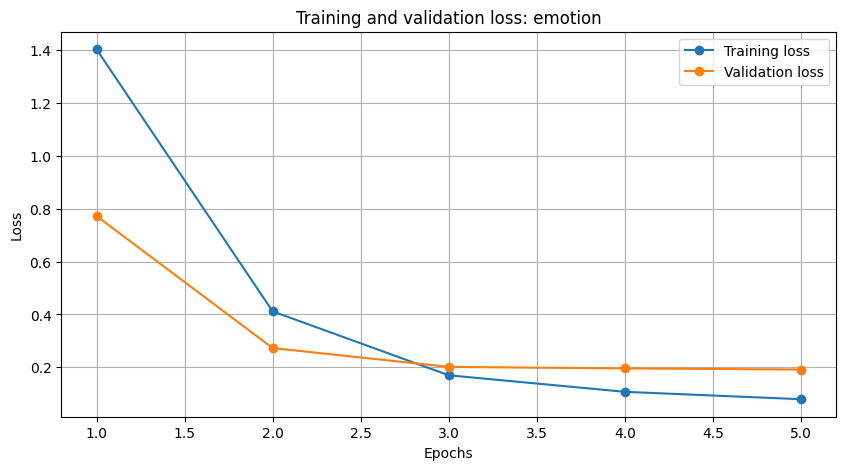


--- Final evaluation for EMOTION (Best weights) ---
              precision    recall  f1-score   support

     sadness       0.96      0.94      0.95       581
         joy       0.94      0.94      0.94       695
        love       0.83      0.84      0.83       159
       anger       0.91      0.93      0.92       275
        fear       0.90      0.88      0.89       224
    surprise       0.72      0.86      0.79        66

    accuracy                           0.92      2000
   macro avg       0.88      0.90      0.89      2000
weighted avg       0.92      0.92      0.92      2000



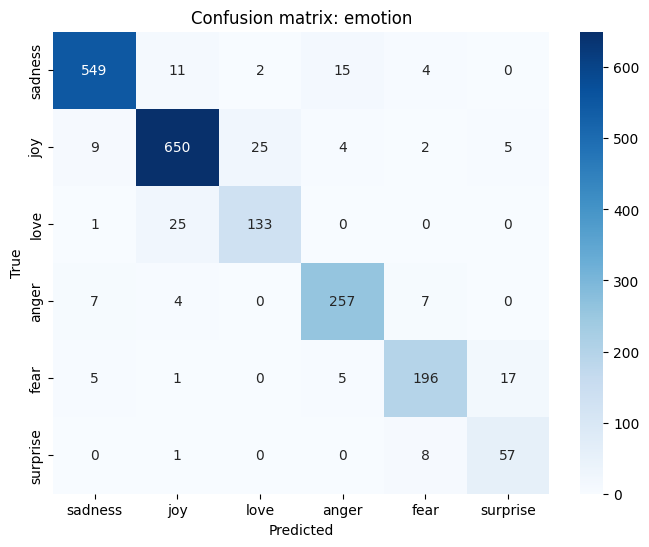

--- Generating lime visual for emotion ---


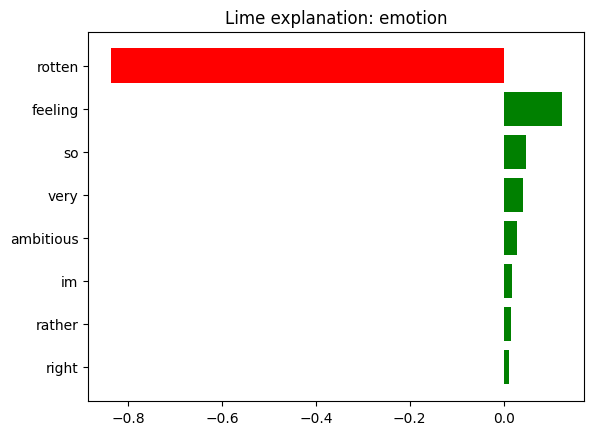


########################################
 PROCESSING DATASET: IMDB 
########################################


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Epoch 1 | Val Acc: 0.7800 (Best model saved)
Epoch 2 | Val Acc: 0.8200 (Best model saved)
Epoch 3 | Val Acc: 0.8344
Epoch 4 | Val Acc: 0.8276
Epoch 5 | Val Acc: 0.8224


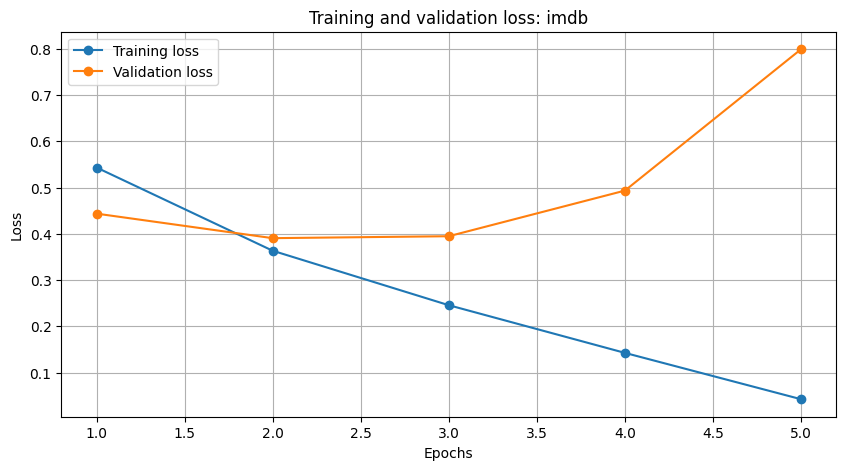


--- Final evaluation for IMDB (Best weights) ---
              precision    recall  f1-score   support

    negative       0.80      0.83      0.82     12500
    positive       0.83      0.80      0.81     12500

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.81     25000
weighted avg       0.81      0.81      0.81     25000



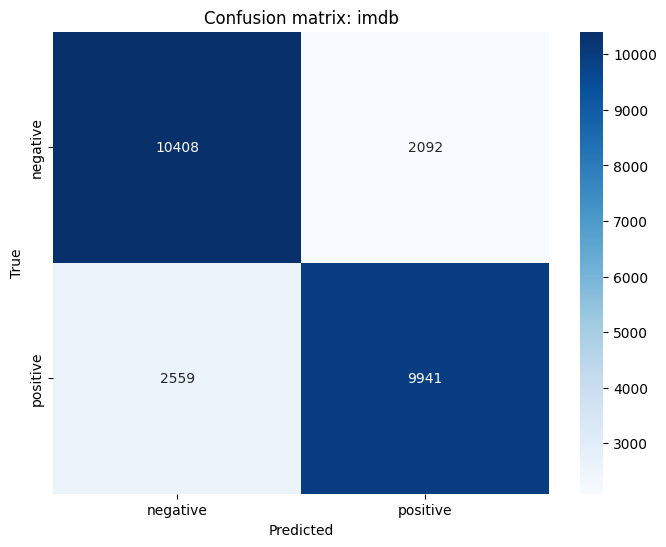

--- Generating lime visual for imdb ---


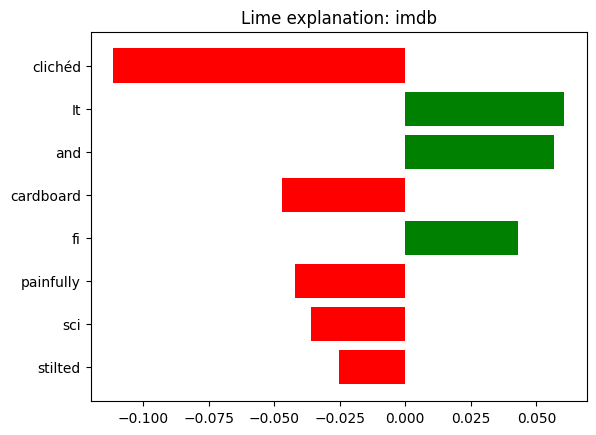


########################################
 PROCESSING DATASET: SST2 
########################################


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Epoch 1 | Val Acc: 0.8188 (Best model saved)
Epoch 2 | Val Acc: 0.8349 (Best model saved)
Epoch 3 | Val Acc: 0.8326 (Best model saved)
Epoch 4 | Val Acc: 0.8314
Epoch 5 | Val Acc: 0.8429 (Best model saved)


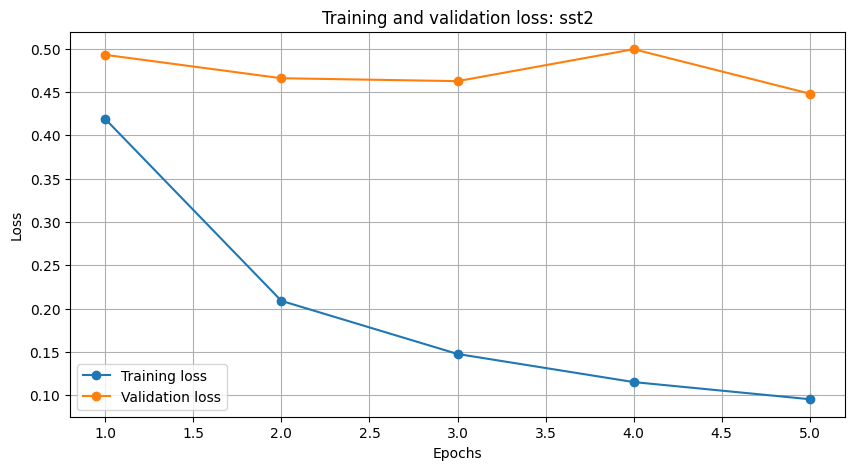


--- Final evaluation for SST2 (Best weights) ---
              precision    recall  f1-score   support

    negative       0.84      0.84      0.84       428
    positive       0.85      0.84      0.85       444

    accuracy                           0.84       872
   macro avg       0.84      0.84      0.84       872
weighted avg       0.84      0.84      0.84       872



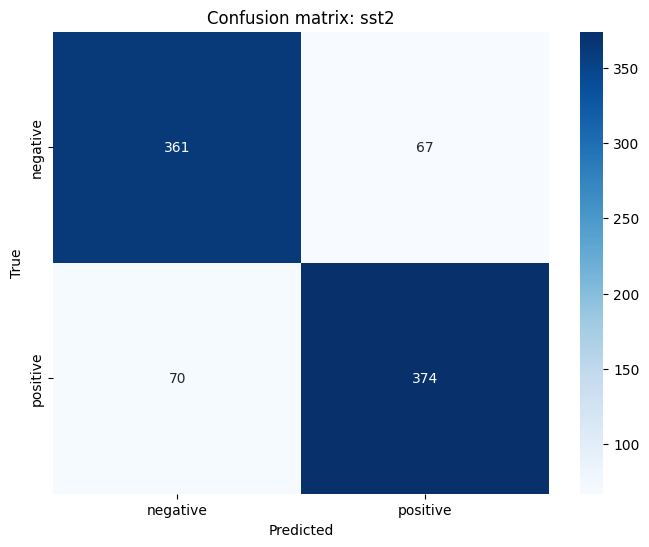

--- Generating lime visual for sst2 ---


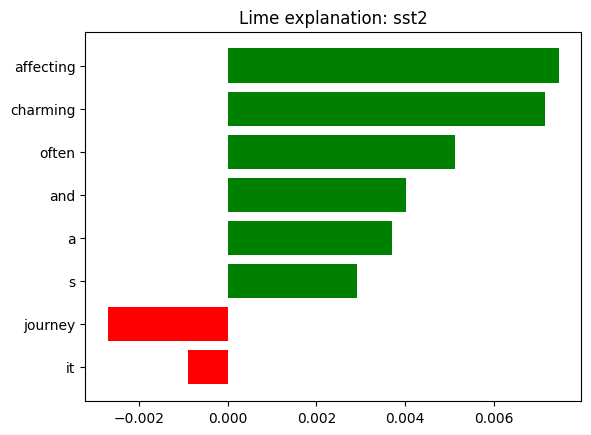

In [5]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import gc

datasets_to_process = ["emotion", "imdb", "sst2"]

for ds_name in datasets_to_process:
    print(f"\n{'#'*40}")
    print(f" PROCESSING DATASET: {ds_name.upper()} ")
    print(f"{'#'*40}")
    
    # --- 1. Load data ---
    train_df = pd.read_csv(f"{BASE_PATH}/{ds_name}_train.csv")
    val_df = pd.read_csv(f"{BASE_PATH}/{ds_name}_val.csv")
    test_df = pd.read_csv(f"{BASE_PATH}/{ds_name}_test.csv")
    
    train_loader = DataLoader(TextDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TextDataset(val_df), batch_size=BATCH_SIZE)
    test_loader = DataLoader(TextDataset(test_df), batch_size=BATCH_SIZE)
    
    # --- 2. Initialize model, optimizer, and scheduler ---
    num_classes = len(MAPPINGS[ds_name])
    model = BiLSTMAttention(tokenizer.vocab_size, 100, 128, num_classes).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
    criterion = nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_model_path = f"bilstm_{ds_name}_best.pth"

    # --- 3. Training loop ---
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        for batch in train_loader:
            ids, labels = batch['input_ids'].to(DEVICE), batch['label'].to(DEVICE)
            optimizer.zero_grad()
            outputs = model(ids)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation phase
        model.eval()
        val_loss = 0
        correct = 0
        with torch.no_grad():
            for batch in val_loader:
                ids, labels = batch['input_ids'].to(DEVICE), batch['label'].to(DEVICE)
                outputs = model(ids)
                v_loss = criterion(outputs, labels)
                val_loss += v_loss.item()
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = correct / len(val_df)
        
        scheduler.step(avg_val_loss)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f"Epoch {epoch+1} | Val Acc: {avg_val_acc:.4f} (Best model saved)")
        else:
            print(f"Epoch {epoch+1} | Val Acc: {avg_val_acc:.4f}")

    # --- 4. Plot training vs validation loss ---
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, EPOCHS + 1), history['train_loss'], label='Training loss', marker='o')
    plt.plot(range(1, EPOCHS + 1), history['val_loss'], label='Validation loss', marker='o')
    plt.title(f'Training and validation loss: {ds_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{ds_name}_loss_plot.png")
    plt.show()

    # --- 5. Final evaluation and confusion matrix ---
    print(f"\n--- Final evaluation for {ds_name.upper()} (Best weights) ---")
    model.load_state_dict(torch.load(best_model_path))
    model.eval()
    
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in test_loader:
            ids, labels = batch['input_ids'].to(DEVICE), batch['label'].to(DEVICE)
            outputs = model(ids)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    class_names = list(MAPPINGS[ds_name].values())
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Plotting confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion matrix: {ds_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(f"{ds_name}_confusion_matrix.png")
    plt.show()

    # --- 6. Lime explanation visual plot ---
    print(f"--- Generating lime visual for {ds_name} ---")
    def predictor(texts):
        model.eval()
        tk = tokenizer(texts, padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            logits = model(tk['input_ids'])
            probs = F.softmax(logits, dim=1)
        return probs.cpu().numpy()

    explainer = LimeTextExplainer(class_names=class_names)
    sample_text = test_df.iloc[0]['text']
    exp = explainer.explain_instance(sample_text, predictor, num_features=8)
    fig = exp.as_pyplot_figure()
    plt.title(f"Lime explanation: {ds_name}")
    plt.show()
    
    # Cleanup memory
    del model, train_loader, val_loader, test_loader, train_df, val_df, test_df
    gc.collect()
    torch.cuda.empty_cache()